<a href="https://colab.research.google.com/github/j-weigel/Evol.-Computing/blob/main/EvoCompPlayground.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Pumpkin Problem (relocated):


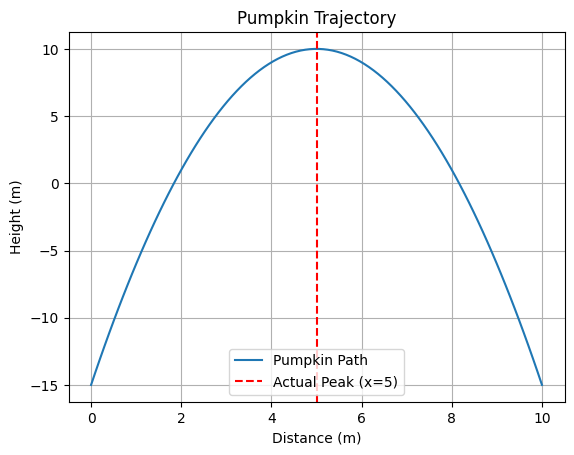

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Define our pumpkin function
def f(x):
    return 10 - (x - 5)**2 # 𝑓(𝑥)=10−(𝑥−5)^2

# Define the derivative (needed for Newton and Gradient Descent)
# f'(x) = -2(x - 2)
def df(x):
    return -2 * (x - 5) # Corrected to use multiplication operator

# Define the second derivative (needed for Newton's Method)
# f''(x) = -2
def ddf(x):
    return -2

# Let's visualize the pumpkin's flight first!
x_vals = np.linspace(0,10, 100)
plt.plot(x_vals, f(x_vals), label='Pumpkin Path')
plt.axvline(5, color='red', linestyle='--', label='Actual Peak (x=5)')
plt.title("Pumpkin Trajectory")
plt.xlabel("Distance (m)")
plt.ylabel("Height (m)")
plt.legend()
plt.grid(True)
plt.show()


# REFLECTION —
# Take-home:
# Changing the surface changes the location of the optimum, but the
# algorithm itself does not need to change. We only give it the new
# function, derivatives, and account for where the new optima will be.

## Multiple Peaks / Gradient Ascent :



PLAY SESSION 2: A BUMPY SURFACE
Start x =  -5.0 -> final x =  -2.8623, f(x) =   5.3594
Start x =  -2.0 -> final x =  -2.1464, f(x) =   6.3704
Start x =   2.0 -> final x =  -1.4271, f(x) =   5.9493


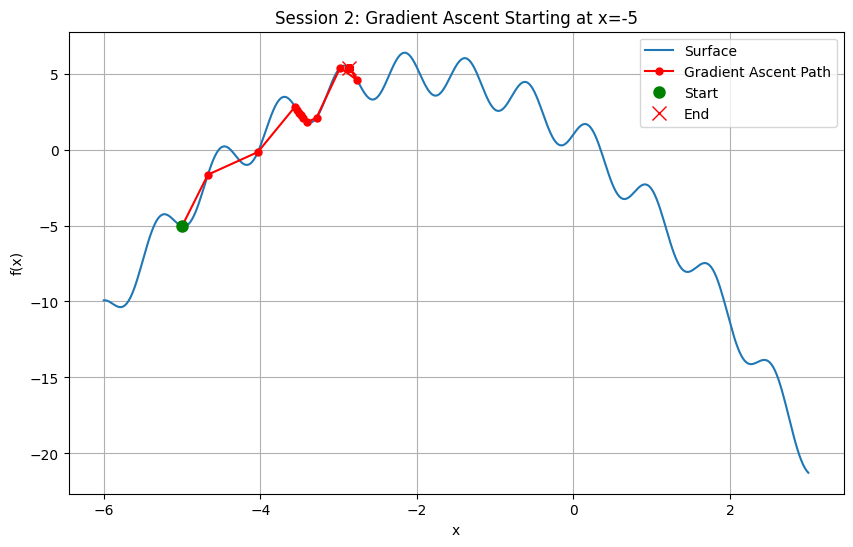

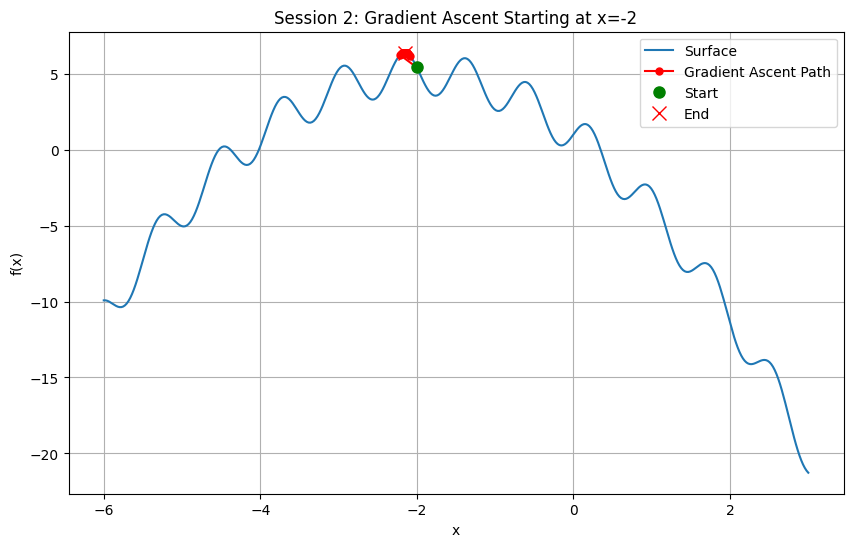

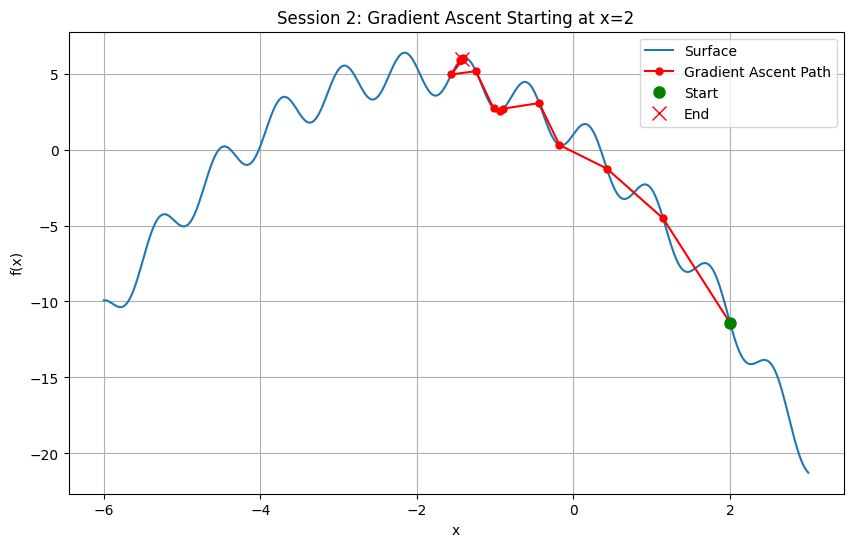

In [15]:
# Explore what happens when a surface has MORE THAN ONE peak.
#
# New surface:
#
#     f(x) = -(x + 2)^2 + 5 + 0.7 * sin(2x)
#
# The sinusoidal term creates bumps in the surface.
# This means the surface is no longer a simple parabola.
#
# For this session, we calculate the derivatives analytically.
def session_2_surface(x):
    return -(x + 2) ** 2 + 5 + 1.4 * np.sin(8 * x)


def session_2_df(x):
    return -2 * (x + 2) + 2.8 * np.cos(8 * x)


def session_2_ddf(x):
    return -2 - 5.6 * np.sin(8 * x)


# Define a general gradient ascent function that accepts the surface and derivative functions
def gradient_ascent(surface_func, derivative_func, start_x, learning_rate=0.1, steps=20):
    x = start_x
    history = [x]

    for i in range(steps):
        # Move x in the direction of the positive slope
        x = x + learning_rate * derivative_func(x)
        history.append(x)

    return x, history


def plot_surface(surface_func, x_min, x_max, title, path=None):
    x_vals = np.linspace(x_min, x_max, 400)
    y_vals = surface_func(x_vals)

    plt.figure(figsize=(10, 6))
    plt.plot(x_vals, y_vals, label='Surface')
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.grid(True)

    if path is not None:
        path_x = np.array(path)
        path_y = surface_func(path_x)
        plt.plot(path_x, path_y, 'ro-', markersize=5, label='Gradient Ascent Path')
        plt.plot(path_x[0], path_y[0], 'go', markersize=8, label='Start')
        plt.plot(path_x[-1], path_y[-1], 'rx', markersize=10, label='End')
        plt.legend()
    plt.show()


# Run gradient ascent from THREE different starting points.
# This is intentional: starting location can matter on a complex surface.
session_2_starts = [-5, -2, 2]
session_2_results = []

print("\n" + "=" * 60)
print("PLAY SESSION 2: A BUMPY SURFACE")
print("=" * 60)

for start in session_2_starts:
    peak, path = gradient_ascent(
        session_2_surface,
        session_2_df,
        start_x=start,
        learning_rate=0.08,
        steps=80,
    )

    session_2_results.append((start, peak, path))

    print(
        f"Start x = {start:5.1f} -> "
        f"final x = {peak:8.4f}, "
        f"f(x) = {session_2_surface(peak):8.4f}"
    )

# Plot the three paths separately so we can compare how starting point
# changes the search.
for start, peak, path in session_2_results:
    plot_surface(
        session_2_surface,
        -6,
        3,
        f"Session 2: Gradient Ascent Starting at x={start}",
        path,
    )


## Learning Rate Changes:


PLAY SESSION 5: LEARNING-RATE EXPERIMENT
Learning rate = 0.05 -> final x =   2.3921, f(x) =   4.6305


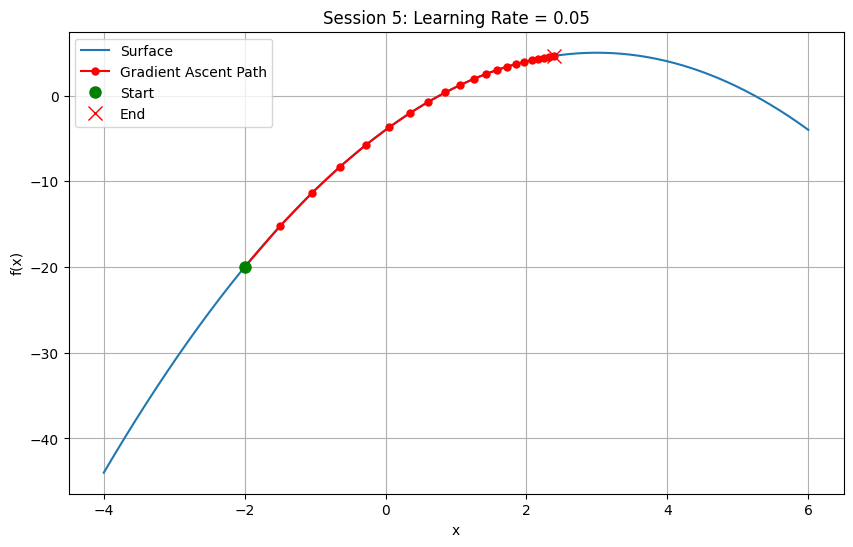

Learning rate = 0.20 -> final x =   2.9998, f(x) =   5.0000


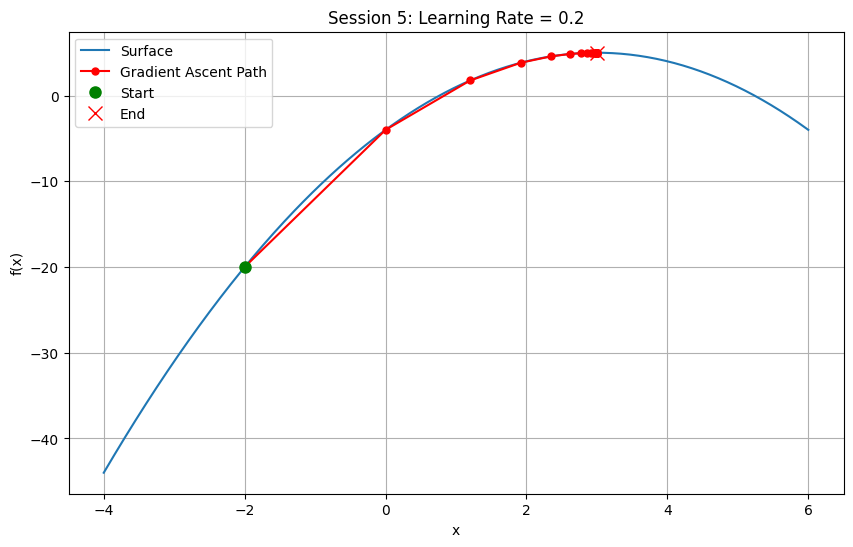

Learning rate = 0.80 -> final x =   2.9998, f(x) =   5.0000


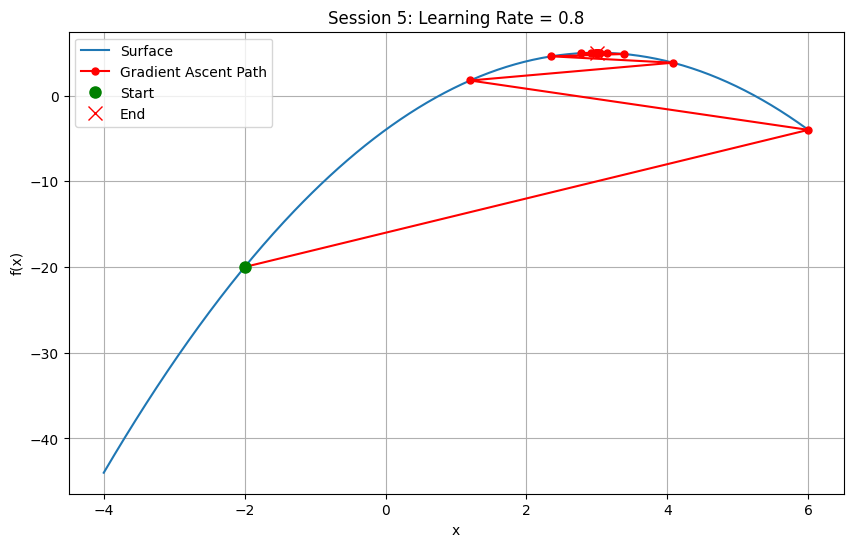

In [16]:
def session_5_surface(x):
    return 5 - (x - 3) ** 2


def session_5_df(x):
    return -2 * (x - 3)


print("\n" + "=" * 60)
print("PLAY SESSION 5: LEARNING-RATE EXPERIMENT")
print("=" * 60)

learning_rates = [0.05, 0.2, 0.8]

for rate in learning_rates:
    peak, path = gradient_ascent(
        session_5_surface,
        session_5_df,
        start_x=-2,
        learning_rate=rate,
        steps=20,
    )

    print(
        f"Learning rate = {rate:4.2f} -> "
        f"final x = {peak:8.4f}, "
        f"f(x) = {session_5_surface(peak):8.4f}"
    )

    plot_surface(
        session_5_surface,
        -4,
        6,
        f"Session 5: Learning Rate = {rate}",
        path,
    )

## Guess and Check:


In [17]:
# A list of horizontal distances we want to test
guesses = [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0
           ]

# A list (vector) to store our results
heights = []

print("Manual Guessing Results:")
print("-----------------------")

for x_guess in guesses:
    height = f(x_guess)
    heights.append(height)
    print(f"At x = {x_guess}m, the pumpkin height is {height}m")

# Use the max function to find the highest value in our vector
max_height = max(heights)
print(f"\nThe maximum height we found by guessing was: {max_height}m")

# Encouragement for students:
# We stored all heights in the 'heights' list.
# This allows us to use functions like max() to search through our data!


Manual Guessing Results:
-----------------------
At x = 0.0m, the pumpkin height is -15.0m
At x = 1.0m, the pumpkin height is -6.0m
At x = 2.0m, the pumpkin height is 1.0m
At x = 3.0m, the pumpkin height is 6.0m
At x = 4.0m, the pumpkin height is 9.0m
At x = 5.0m, the pumpkin height is 10.0m
At x = 6.0m, the pumpkin height is 9.0m
At x = 7.0m, the pumpkin height is 6.0m

The maximum height we found by guessing was: 10.0m


## Gradient Descent:


In [18]:
def df(x):
    return -2 * (x - 5) # Corrected derivative for f(x) = 10 - (x - 5)**2

def gradient_ascent(start_x, learning_rate=0.1, steps=20):
    x = start_x
    history = [x]

    for i in range(steps):
        # Move x in the direction of the positive slope
        x = x + learning_rate * df(x)
        history.append(x)
        if i % 5 == 0: # Print every 5 steps
            print(f"Step {i}: x = {x:.4f}")

    return x, history

# Try it out! You can change the learning_rate to see how it affects speed.
peak_grad, path = gradient_ascent(start_x=0.1, learning_rate=0.2)
print(f"\nGradient Ascent found peak at: {peak_grad:.4f}")

Step 0: x = 2.0600
Step 5: x = 4.7714
Step 10: x = 4.9822
Step 15: x = 4.9986

Gradient Ascent found peak at: 4.9998


## Bisection Method:

In [19]:
def bisection_method(a, b, tolerance=0.01):
    # We look for where the derivative df(x) is 0
    if df(a) * df(b) > 0:
        print("The peak might not be between these points!")
        return None

    while (b - a) / 2 > tolerance:
        midpoint = (a + b) / 2
        if df(midpoint) == 0:
            return midpoint
        elif df(a) * df(midpoint) < 0:
            b = midpoint # The peak is in the left half
        else:
            a = midpoint # The peak is in the right half

    return (a + b) / 2

# Try it out with a range from 0 to 5
peak_bisect = bisection_method(0, 5)
print(f"Bisection Method found peak near: {peak_bisect:.4f}")

Bisection Method found peak near: 4.9902


## Newton's Method:


In [20]:
def newtons_method(start_x, iterations=5):
    x = start_x
    print(f"Starting Newton's Method at x = {x}")

    for i in range(iterations):
        # Newton's update rule for optimization: x = x - f'(x) / f''(x)
        x = x - df(x) / ddf(x)
        print(f"Iteration {i+1}: x = {x:.4f}, f(x) = {f(x):.4f}")

    return x

# Try it out!
peak_newton = newtons_method(start_x=0.5)
print(f"\nNewton found the peak at: {peak_newton} meters.")

Starting Newton's Method at x = 0.5
Iteration 1: x = 5.0000, f(x) = 10.0000
Iteration 2: x = 5.0000, f(x) = 10.0000
Iteration 3: x = 5.0000, f(x) = 10.0000
Iteration 4: x = 5.0000, f(x) = 10.0000
Iteration 5: x = 5.0000, f(x) = 10.0000

Newton found the peak at: 5.0 meters.


Newton's Method was the fastest for this specific function.

Gradient Ascent is the most common in Machine Learning.

Bisection is the most reliable if you don't know the derivative.

Try it yourself: Can you change the pumpkin function to  𝑓(𝑥)=10−(𝑥−5)2  and update the derivatives to find the new peak?

## 2D Demo:
# f(x,y) = (x-2)^2-xy+(y-3)^2

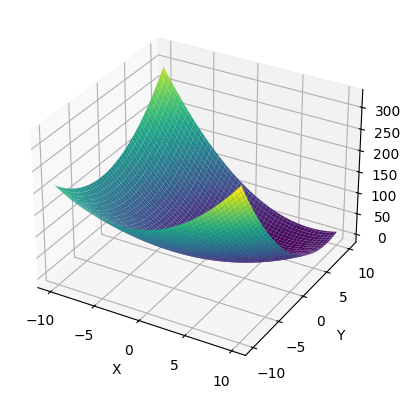

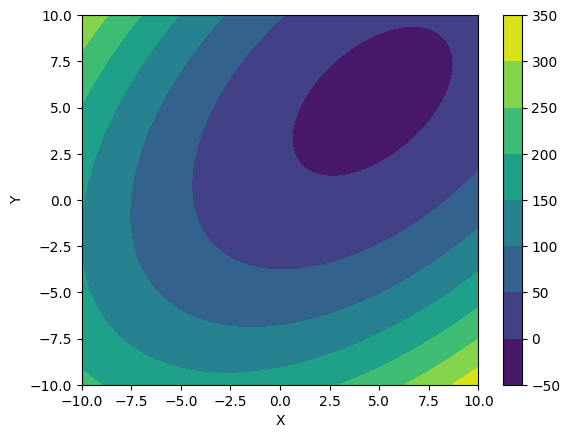

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# creating a landscape
def f(coordinates):
  x, y = coordinates
  return (x-2)**2 - x*y + (y-3)**2

x_range = np.linspace(-10, 10, 100)
y_range = np.linspace(-10, 10, 100)
X, Y = np.meshgrid(x_range, y_range)
Z = f([X, Y])

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()

plt.contourf(X, Y, Z, cmap='viridis')
plt.colorbar()
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

In [22]:
x0 = np.array([0.0, 0.0])

res = minimize(f, x0, method = 'nelder-mead')
print(res)


       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: -12.333333332846038
             x: [ 4.667e+00  5.333e+00]
           nit: 77
          nfev: 151
 final_simplex: (array([[ 4.667e+00,  5.333e+00],
                       [ 4.667e+00,  5.333e+00],
                       [ 4.667e+00,  5.333e+00]]), array([-1.233e+01, -1.233e+01, -1.233e+01]))


## Nelder-mead in Python:

In [23]:
import numpy as np
from scipy.optimize import minimize

# Define target surface function
def f(point):
  x,y = point[0], point[1]
  return (x - 2)**2 - x*y + (y - 3)**2

# Initial guess (starting simplex vertex)
x0 = np.array([0.0, 0.0])

# Execute Nelder-Mead optimization
res = minimize(f, x0, method='Nelder-Mead')

print(f"Minimum at: {res.x}")

Minimum at: [4.66664339 5.3333127 ]


## Gradient Descent on 2D surface:


In [24]:
# Define surface gradient
def grad_f(v):
    x, y = v[0], v[1]
    dx = 2*x - y - 4
    dy = -x + 2*y - 6
    return np.array([dx, dy])
# Parameters
v = np.array([0.0, 0.0])  # Initial guess
alpha = 0.1              # Learning rate
epochs = 20              # Iterations
# 2D Gradient Descent Loop
for epoch in range(epochs):
    grad = grad_f(v)
    v = v - alpha * grad
print(f"Minimum at: {v}")


# Define surface gradient
def grad_f(v):
    x, y = v[0], v[1]
    dx = 2*x - y - 4
    dy = -x + 2*y - 6
    return np.array([dx, dy])
# Parameters
v = np.array([0.0, 0.0])  # Initial guess
alpha = 0.1              # Learning rate
epochs = 20              # Iterations
# 2D Gradient Descent Loop
for epoch in range(epochs):
    grad = grad_f(v)
    v = v - alpha * grad
print(f'minimum at: {v}')


Minimum at: [4.05904937 4.72518409]
minimum at: [4.05904937 4.72518409]


## Newton's method:

final point: [4.66666667 5.33333333]
minimum: -12.333333333333336


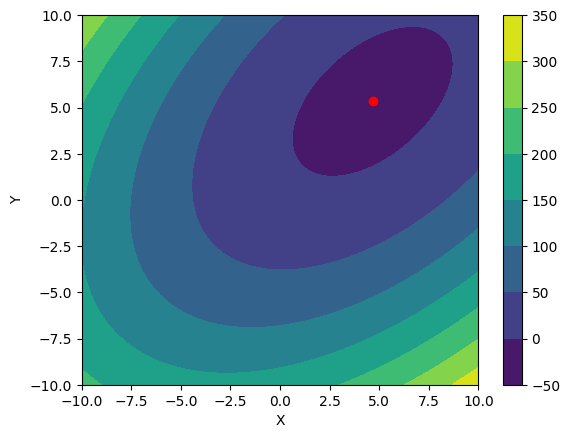

In [25]:
 #Define Gradient & Hessian

def grad(xy):
  x, y = xy[0], xy[1]
  return np.array([2*(x-2) - y, -x + 2*(y-3)])

def hessian(xy):
  return np.array([[2.0, -1.0], [-1.0, 2.0]])

# Iteration Step
xy = np.array([0.0, 0.0])

for _ in range(5):
  g = grad(xy)
  h  = hessian(xy)
xy = xy - np.linalg.solve(h, g)

print('final point:',xy)
print('minimum:',f(xy))

plt.contourf(X, Y, Z, cmap='viridis')
plt.colorbar()
plt.xlabel('X')
plt.ylabel('Y')
plt.plot(xy[0], xy[1], 'ro')
plt.show()

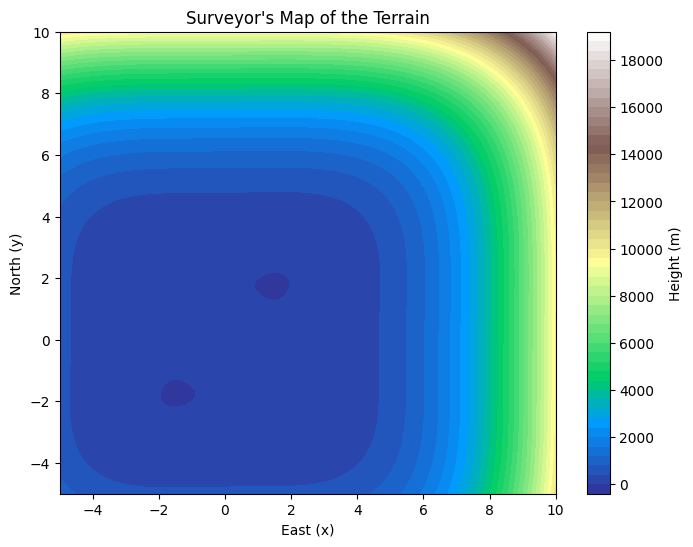

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Define our terrain height function
def f(coords):
    x, y = coords
    return (x**2 - 2)**2 - x*y + (y**2 - 3)**2

# Let's visualize the terrain first!
x_range = np.linspace(-5, 10, 100)
y_range = np.linspace(-5, 10, 100)
X, Y = np.meshgrid(x_range, y_range)
Z = f([X, Y])

plt.figure(figsize=(8, 6))
plt.contourf(X, Y, Z, levels=50, cmap='terrain')
plt.colorbar(label='Height (m)')
plt.title('Surveyor\'s Map of the Terrain')
plt.xlabel('East (x)')
plt.ylabel('North (y)')
plt.show()

In [63]:
# We start at an arbitrary guess: (0, 0)
initial_guess = [0, 0]

# Nelder-Mead is a 'Direct Search' method (no derivatives needed!)
result_nm = minimize(f, initial_guess, method='Nelder-Mead')

print(f"Nelder-Mead found the minimum at x = {result_nm.x[0]:.2f}, y = {result_nm.x[1]:.2f}")
print(f"The height at this point is {result_nm.fun:.2f} meters.")

Nelder-Mead found the minimum at x = 1.52, y = 1.79
The height at this point is -2.58 meters.


In [53]:
# In the Gradient Descent cell, change 0.1 to 0.8 or 0.001. Does it still find the bottom?
# New Terrain: Can you change the f(coords) function to x**2 + y**2 and see if the code still works?

def gradient(coords):
    x, y = coords
    # These formulas represent how steep the hill is in the x and y directions
    df_dx = 2*(x - 2) - y
    df_dy = -x + 2*(y - 3)
    return np.array([df_dx, df_dy])

# Simple Gradient Descent Loop
position = np.array([0.0, 0.0]) # Starting point
learning_rate = .1             # How big each step is

for i in range(50):
    grad = gradient(position)
    position = position - learning_rate * grad # Step away from the 'uphill' direction

print(f"Gradient Descent found the minimum at x = {position[0]:.2f}, y = {position[1]:.2f}")

Gradient Descent found the minimum at x = 4.64, y = 5.31
